In [7]:
# Завантаження та pivot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler

# Завантаження
df = pd.read_excel('CTR_dataset.xlsx')
print(f"Рядків: {len(df)}, Груп: {df['user_group'].nunique()}, Банерів: {df['banner'].nunique()}")

# Pivot: рядки = групи, колонки = банери, значення = CTR
pivot = df.pivot_table(index='user_group', columns='banner', values='CTR')
print(f"\nРозмір pivot таблиці: {pivot.shape}")
print(f"Пропусків (NaN): {pivot.isna().sum().sum()}")

# Заповнюємо NaN нулями - якщо група не мала показів по банеру, CTR = 0
pivot_filled = pivot.fillna(0)
pivot_filled.head()

Рядків: 1680, Груп: 42, Банерів: 40

Розмір pivot таблиці: (42, 40)
Пропусків (NaN): 0


banner,banner_a,banner_aa,banner_ab,banner_ac,banner_ad,banner_ae,banner_af,banner_ag,banner_ah,banner_ai,...,banner_q,banner_r,banner_s,banner_t,banner_u,banner_v,banner_w,banner_x,banner_y,banner_z
user_group,,,,,,,,,,,,,,,,,,,,,
Group_1,0.067761,0.027119,0.026940,0.025819,0.026973,0.026413,0.024403,0.024559,0.025861,0.023659,...,0.036019,0.035140,0.032455,0.030769,0.031093,0.031422,0.029358,0.029951,0.029116,0.028313
Group_10,0.068591,0.026615,0.027362,0.026102,0.025773,0.026485,0.026180,0.024340,0.024884,0.025387,...,0.035315,0.034039,0.033487,0.033101,0.032421,0.031733,0.030325,0.030018,0.028209,0.028125
Group_11,0.066980,0.027397,0.027203,0.026260,0.026785,0.026422,0.025241,0.025615,0.024465,0.025577,...,0.035815,0.033081,0.033518,0.032712,0.030940,0.031008,0.028959,0.028253,0.028207,0.028373
Group_12,0.068026,0.028232,0.027657,0.026547,0.026875,0.026520,0.025329,0.025906,0.024563,0.025566,...,0.034451,0.034339,0.033063,0.032240,0.031699,0.030620,0.031103,0.029281,0.028178,0.028047
Group_13,0.071477,0.031840,0.027375,0.026185,0.024847,0.025828,0.028901,0.024466,0.025111,0.024539,...,0.041564,0.034943,0.032335,0.032614,0.032100,0.029671,0.030089,0.028037,0.028154,0.028717


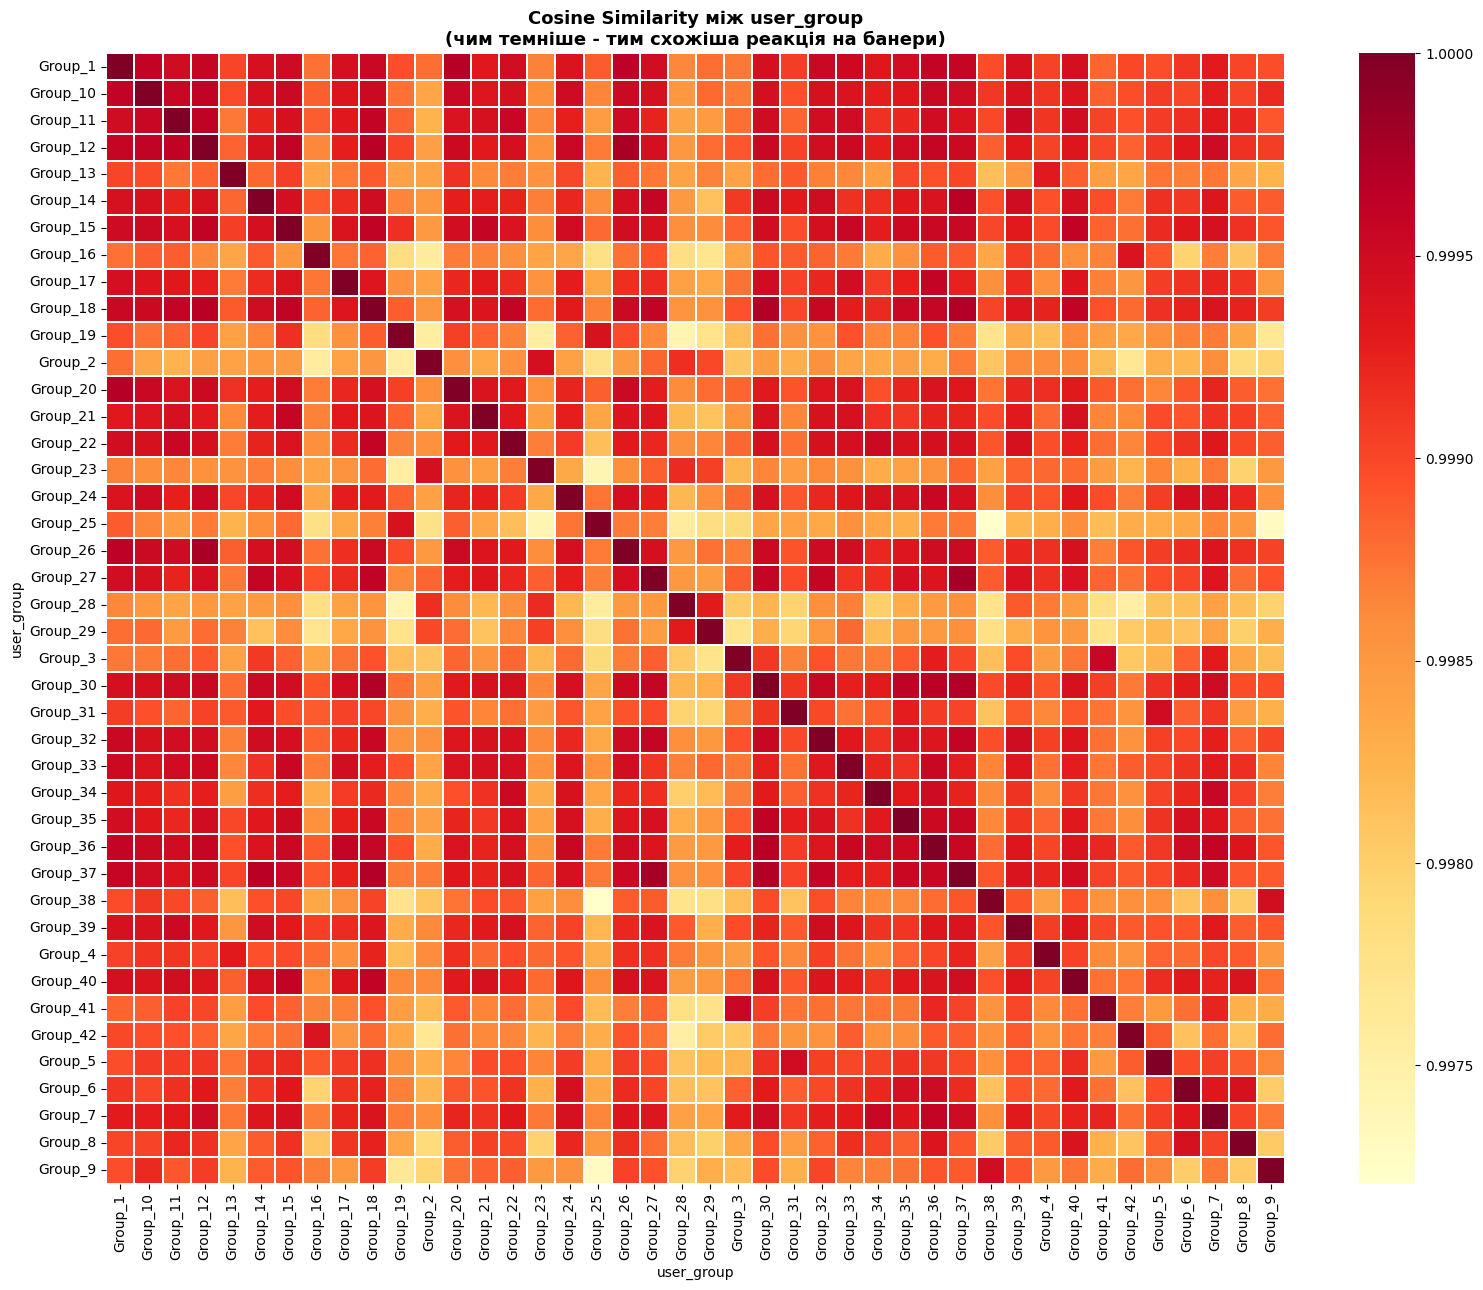


Середня подібність між групами: 0.999


In [8]:
# Cosine Similarity між групами
from sklearn.metrics.pairwise import cosine_similarity

# Cosine similarity: наскільки схожа реакція двох груп на ті самі банери
cos_sim = cosine_similarity(pivot_filled)
cos_sim_df = pd.DataFrame(cos_sim, index=pivot_filled.index, columns=pivot_filled.index)

# Heatmap подібності
plt.figure(figsize=(16, 13))
sns.heatmap(
    cos_sim_df,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.3,
    xticklabels=True,
    yticklabels=True
)
plt.title('Cosine Similarity між user_group\n(чим темніше - тим схожіша реакція на банери)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('cosine_similarity.png', dpi=150)
plt.show()

print(f"\nСередня подібність між групами: {cos_sim[cos_sim < 1].mean():.3f}")

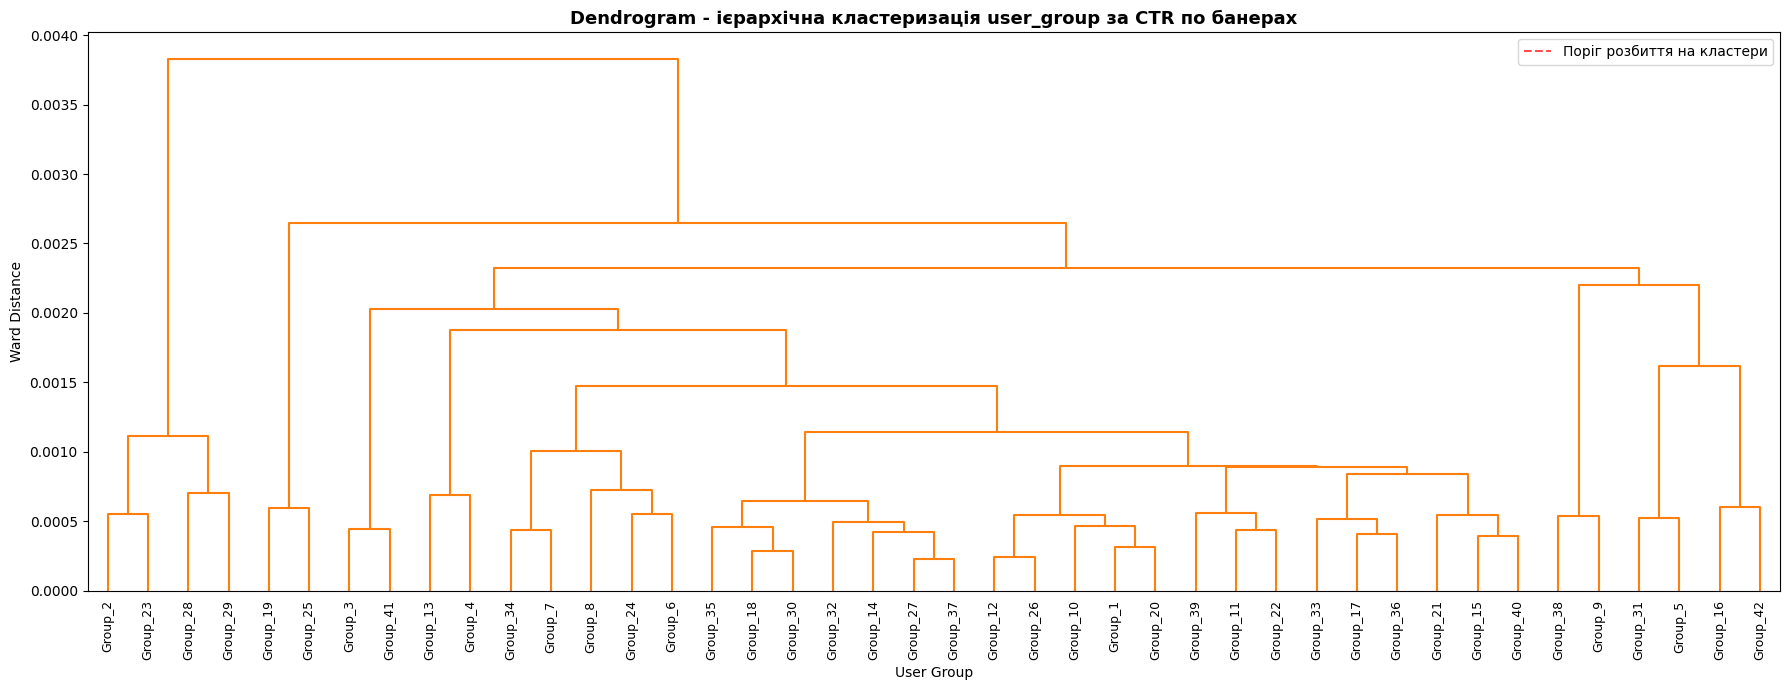

In [9]:
# Ієрархічна кластеризація + Dendrogram
# Відстань = 1 - cosine_similarity (чим ближче до 0, тим схожіші)
distance_matrix = 1 - cos_sim_df.values
np.fill_diagonal(distance_matrix, 0)

# Linkage для ієрархічної кластеризації
condensed = pdist(pivot_filled.values, metric='cosine')
Z = linkage(condensed, method='ward')

# Dendrogram
plt.figure(figsize=(18, 7))
dendrogram(
    Z,
    labels=pivot_filled.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=0.8
)
plt.title('Dendrogram - ієрархічна кластеризація user_group за CTR по банерах', fontweight='bold', fontsize=13)
plt.xlabel('User Group')
plt.ylabel('Ward Distance')
plt.axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='Поріг розбиття на кластери')
plt.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150)
plt.show()

=== РОЗПОДІЛ ГРУП ПО КЛАСТЕРАХ ===

Кластер 1 (4 груп): Group_23, Group_2, Group_28, Group_29
Кластер 2 (2 груп): Group_19, Group_25
Кластер 3 (30 груп): Group_13, Group_1, Group_17, Group_15, Group_14, Group_18, Group_21, Group_10, Group_11, Group_12, Group_32, Group_22, Group_20, Group_24, Group_27, Group_26, Group_3, Group_30, Group_37, Group_33, Group_34, Group_35, Group_36, Group_40, Group_4, Group_39, Group_7, Group_6, Group_8, Group_41
Кластер 4 (6 груп): Group_38, Group_31, Group_16, Group_5, Group_42, Group_9


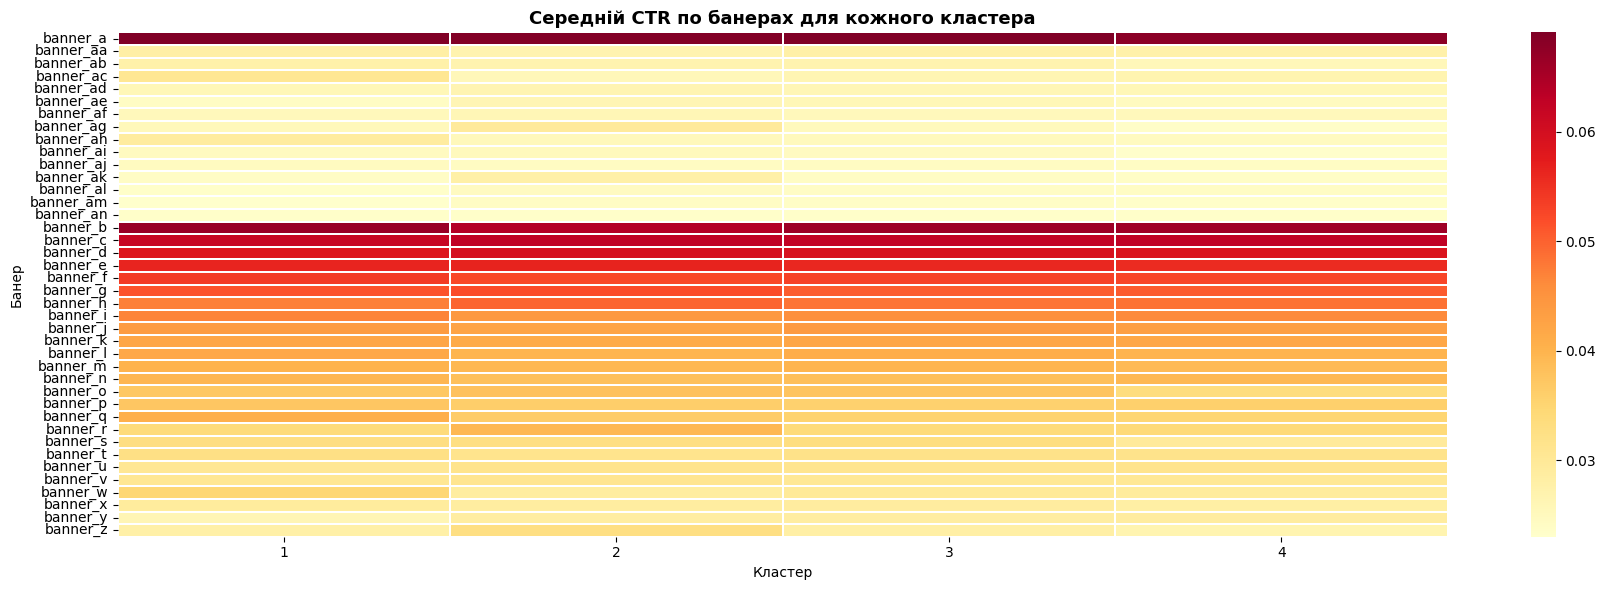

In [10]:
# Розбиття на кластери та аналіз
# Розбиваємо на 4 кластери (видно з dendrogram)
n_clusters = 4
cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')

pivot_filled['cluster'] = cluster_labels

cluster_df = pd.DataFrame({
    'user_group': pivot_filled.index,
    'cluster': cluster_labels
}).sort_values('cluster')

print("=== РОЗПОДІЛ ГРУП ПО КЛАСТЕРАХ ===\n")
for c in sorted(cluster_df['cluster'].unique()):
    groups = cluster_df[cluster_df['cluster']==c]['user_group'].tolist()
    print(f"Кластер {c} ({len(groups)} груп): {', '.join(groups)}")

# Середній CTR по банерах для кожного кластера
pivot_with_cluster = pivot_filled.copy()
cluster_profile = pivot_with_cluster.groupby('cluster').mean()

plt.figure(figsize=(18, 6))
sns.heatmap(
    cluster_profile.T,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.3,
    yticklabels=True
)
plt.title('Середній CTR по банерах для кожного кластера', fontweight='bold', fontsize=13)
plt.xlabel('Кластер')
plt.ylabel('Банер')
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150)
plt.show()

In [12]:
# Висновки
print("""
=== УТОЧНЕНИЙ АНАЛІЗ РЕЗУЛЬТАТІВ ===

КЛЮЧОВЕ СПОСТЕРЕЖЕННЯ:
Середня cosine similarity між усіма групами = 0.999
Це означає що всі 42 групи реагують на банери практично однаково.
CTR варіюється у вузькому діапазоні (~0.025 - 0.075) для всіх груп і банерів.

ЩО ЦЕ ОЗНАЧАЄ ПРАКТИЧНО:
- Немає груп з принципово різною реакцією на рекламу
- Аудиторія однорідна з точки зору банерного CTR
- 4 кластери технічно існують але різниця між ними мінімальна

НАЙБІЛЬШ ВІДМІННІ ГРУПИ (потенційні аутлаєри):
- Кластер 1 (Group_2, Group_23, Group_28, Group_29) - злиплися першими,
  найбільш схожі між собою
- Кластер 2 (Group_19, Group_25) - найбільш відмінні від решти,
  варто перевірити їх CTR окремо

РЕКОМЕНДАЦІЯ:
Замість кластеризації по CTR-паттерну, більш корисним було б
збагатити датасет додатковими ознаками: демографія групи,
платформа, гео - це дало б змістовніші кластери.
""")

# Перевіримо аутлаєри - групи з найвищим і найнижчим середнім CTR
mean_ctr = pivot_filled.drop(columns='cluster', errors='ignore').mean(axis=1).sort_values(ascending=False)
print("Топ-5 груп з найвищим середнім CTR:")
print(mean_ctr.head())
print("\nТоп-5 груп з найнижчим середнім CTR:")
print(mean_ctr.tail())


=== УТОЧНЕНИЙ АНАЛІЗ РЕЗУЛЬТАТІВ ===

КЛЮЧОВЕ СПОСТЕРЕЖЕННЯ:
Середня cosine similarity між усіма групами = 0.999
Це означає що всі 42 групи реагують на банери практично однаково.
CTR варіюється у вузькому діапазоні (~0.025 - 0.075) для всіх груп і банерів.

ЩО ЦЕ ОЗНАЧАЄ ПРАКТИЧНО:
- Немає груп з принципово різною реакцією на рекламу
- Аудиторія однорідна з точки зору банерного CTR
- 4 кластери технічно існують але різниця між ними мінімальна

НАЙБІЛЬШ ВІДМІННІ ГРУПИ (потенційні аутлаєри):
- Кластер 1 (Group_2, Group_23, Group_28, Group_29) - злиплися першими,
  найбільш схожі між собою
- Кластер 2 (Group_19, Group_25) - найбільш відмінні від решти,
  варто перевірити їх CTR окремо

РЕКОМЕНДАЦІЯ:
Замість кластеризації по CTR-паттерну, більш корисним було б
збагатити датасет додатковими ознаками: демографія групи,
платформа, гео - це дало б змістовніші кластери.

Топ-5 груп з найвищим середнім CTR:
user_group
Group_23    0.037019
Group_2     0.036954
Group_19    0.036860
Group_4     0.